# Nowcasting with `pynowcast` — a full forecasting exercise

This notebook walks through a **complete nowcasting workflow** with
`pynowcast`, a Python re-implementation of the ECB nowcasting toolbox
(Linzenich & Meunier, 2024, *ECB Working Paper 3004*).

The exercise follows the natural order of a real nowcasting round:

1. **Data import** — load the mixed-frequency dataset.
2. **Data processing & transformation** — inspect transforms, treat Covid-19
   and outliers.
3. **Variable pre-selection** — rank candidate indicators (SIS / t-stat / LARS).
4. **Model selection** — search specifications out-of-sample.
5. **Selected model fit** — estimate the chosen model and produce a nowcast.
6. **Model evaluation** — pseudo-real-time RMSE & FDA across horizons.
7. **Policy interpretation & plots** — news, contributions, heatmap,
   confidence bands, range of alternative models.

Every step lists *what it does* and *what you can configure*. The default
configuration runs on the bundled synthetic dataset in a couple of minutes.

## 0. Setup

`pynowcast` depends only on `numpy`, `scipy` and `pandas`; `matplotlib` is
used for the plots and `openpyxl` to read the Excel template. If you run
this notebook from the repository root, the package is importable directly.

In [1]:
import warnings
warnings.filterwarnings("ignore")           # keep the narrative clean

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pynowcast as pn
from pynowcast import plots

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
print("pynowcast version:", pn.__version__)

pynowcast version: 1.2.0


## 1. Data import

**What it does.** A nowcasting dataset is a *mixed-frequency* panel: many
**monthly** indicators (surveys, industrial production, trade, …) and one or
more **quarterly** series, the first of which is the **target** (here GDP
growth). `pynowcast` stores everything in a `NowcastData` object that aligns
the two frequencies on a common monthly calendar and records, for each
series, its transformation, publication lag and group.

**What you can configure.**
- `pn.load_data("my_file.xlsx", target="GDP")` reads an Excel workbook with
  sheets `monthly`, `quarterly` and `spec` (the format of the original
  toolbox). The `spec` sheet has one row per series with columns
  `transform`, `pub_lag`, `block_<Name>` (factor blocks) and `group`.
- `pn.build_data(raw_monthly, raw_quarterly, spec, target=...)` builds the
  same object directly from in-memory DataFrames.
- Here we use `pn.make_example_dataset()` to generate a reproducible
  synthetic dataset (12 monthly indicators + quarterly GDP) and write it to
  the Excel template, so the rest of the notebook mirrors a real file-based
  workflow.

In [2]:
# generate the bundled synthetic dataset and save it as the Excel template
raw_m, raw_q, spec, truth = pn.make_example_dataset(seed=1)

with pd.ExcelWriter("example_data.xlsx") as xl:
    raw_m.rename_axis("date").to_excel(xl, sheet_name="monthly")
    raw_q.rename_axis("quarter").to_excel(xl, sheet_name="quarterly")
    spec.to_excel(xl, sheet_name="spec")

# import it back, exactly as you would your own file
data = pn.load_data("example_data.xlsx", target="GDP")
print(data.summary().to_string(index=False))

frequency transform first_obs last_obs  n_obs  pub_lag      blocks
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M       pch   2005-02  2026-05    256        2      Global
        M      none   2005-01  2026-05    257        1 Global,Soft
        M      none   2005-01  2026-05    257        1 Global,Soft
        M      none   2005-01  2026-05    257        1 Global,Soft
        M      none   2005-01  2026-05    257        1 Global,Soft
        Q       pch   2005-06  2026-03     84        2      Global


The `spec` sheet drives everything downstream. Note the `transform`,
`pub_lag` and `group` columns — these are what make the pseudo-real-time
vintages, the heatmap and the contributions meaningful.

In [3]:
spec.head(13)

,transform,pub_lag,block_Global,block_Soft,group
series,,,,,
hard_0,pch,2,1,0,Industry
hard_1,pch,2,1,0,Industry
hard_2,pch,2,1,0,Industry
hard_3,pch,2,1,0,Industry
hard_4,pch,2,1,0,Trade
hard_5,pch,2,1,0,Trade
hard_6,pch,2,1,0,Trade
hard_7,pch,2,1,0,Trade
survey_8,none,1,1,1,Surveys


## 2. Data processing & transformation

**What it does.** Raw series are made stationary before modelling. The
transformation of each series is taken from the `transform` column of the
spec and applied automatically by `load_data` / `build_data`:

| code | meaning |
|------|---------|
| `pch`  | quarter/month-on-period log-difference ×100 (growth rate) |
| `pchy` | year-on-year log-difference ×100 |
| `diff` | first difference |
| `none` | leave as is (e.g. survey balances already stationary) |

`data.monthly` and `data.quarterly` already hold the **transformed** data;
`data.transforms` records what was applied.

**What you can configure.** Edit the `transform` column in the spec sheet.
Below we just visualise a transformed indicator and the target.

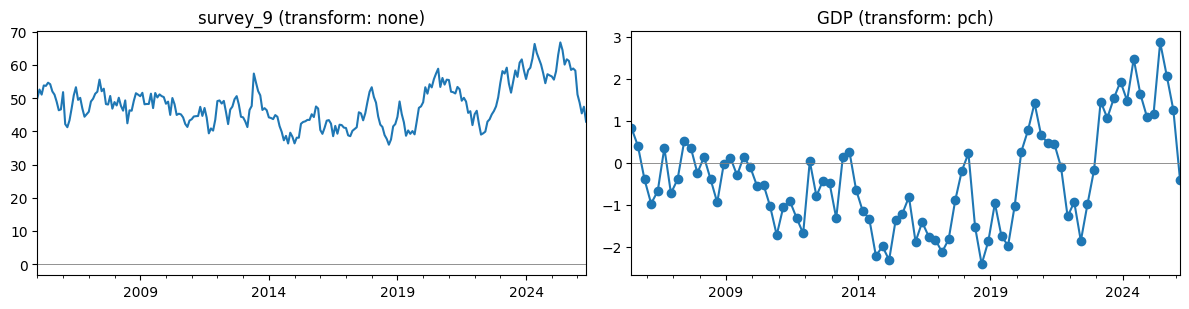

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
data.monthly["survey_9"].plot(ax=axes[0], title="survey_9 (transform: none)")
data.quarterly["GDP"].dropna().plot(ax=axes[1], marker="o",
                                    title="GDP (transform: pch)")
for a in axes:
    a.axhline(0, color="grey", lw=0.6)
plt.tight_layout(); plt.show()

### 2a. Covid-19 treatment

**What it does.** The 2020 swings can distort estimation. `covid_correct`
reproduces the `do_Covid` switch of the original toolbox:

| method | treatment |
|--------|-----------|
| `0` | do nothing |
| `1` | add dummies for 2020 Q2 and Q3 |
| `2` | set Feb–Sep 2020 observations to NaN (the factor models handle the gap) |
| `3` | outlier correction — values beyond median ± 4×inter-quintile distance → NaN |
| `4` | add dummies for 2020 Q1 and Q2 |

Dummies are appended as extra monthly series; for bridge equations pass the
same dates to `BridgeEquations(dummies=[...])`.

**What you can configure.** `method` (0–4), the outlier threshold `k`, and
whether the target itself is corrected (`correct_target`).

> The synthetic dataset has no Covid episode, so the correction is shown for
> illustration; on real euro-area data method 2 or 3 typically helps most.

In [5]:
COVID_METHOD = 2     # try 0, 1, 2, 3, 4

data_c = pn.covid_correct(data, method=COVID_METHOD)
print("series after correction:", data_c.n_monthly, "monthly +",
      data_c.n_quarterly, "quarterly")
if COVID_METHOD in (1, 4):
    print("dummies added:", [c for c in data_c.monthly.columns
                             if c.startswith("dummy")])

series after correction: 12 monthly + 1 quarterly


### 2b. Outlier treatment (any period)

`outlier_correct` applies the same robust rule to a single series outside of
the Covid window — handy for one-off spikes. `detect_outliers` returns the
boolean mask if you only want to flag them.

In [6]:
from pynowcast import outlier_correct, detect_outliers

x = data.monthly["hard_0"]
mask = detect_outliers(x, k=4.0)
print(f"{int(mask.sum())} outliers flagged in hard_0 "
      f"(threshold k=4 inter-quintile distances)")
# x_clean = outlier_correct(x, k=4.0)   # outliers -> NaN

0 outliers flagged in hard_0 (threshold k=4 inter-quintile distances)


In [7]:
# On this synthetic dataset there is no Covid distortion, so we proceed with
# the untreated data. On real data, set:  data = data_c
data_work = data

## 3. Variable pre-selection

**What it does.** Step 1 of the toolbox's three-step approach. With many
candidate indicators it helps to keep the most informative ones.
`preselect` ranks every regressor by three established methods and combines
them into a single score:

- **SIS** — Sure Independence Screening (Fan & Lv, 2008): |marginal
  correlation| with the target.
- **t-stat** (Bair et al., 2006): |t-statistic| in a univariate regression
  that also controls for four lags of the target.
- **LARS** — Least Angle Regression (Efron et al., 2004): order of entry in
  the forward-selection path (accounts for the other predictors).

The combined score weights LARS more heavily, as in the paper. The table
also reports each variable's frequency, publication lag and group.

**What you can configure.** `n_keep` (how many to return) and `weights`
(the weight of each method). `apply_selection(data, names)` then restricts
the dataset — the `do_subset` option.

In [8]:
ranking = pn.preselect(data_work)            # full ranking
ranking.round(3)

,rank_sis,rank_tstat,rank_lars,score,frequency,pub_lag,group
series,,,,,,,
survey_9,1.0,1.0,1.0,1.000,M,1,Surveys
survey_11,2.0,2.0,2.0,0.917,M,1,Surveys
hard_6,3.0,3.0,3.0,0.833,M,2,Trade
hard_3,6.0,6.0,4.0,0.667,M,2,Industry
survey_10,5.0,4.0,6.0,0.646,M,1,Surveys
hard_1,7.0,7.0,5.0,0.583,M,2,Industry
hard_5,8.0,8.0,7.0,0.458,M,2,Trade
survey_8,4.0,5.0,12.0,0.396,M,1,Surveys
hard_4,11.0,11.0,8.0,0.292,M,2,Trade


In [9]:
N_KEEP = 8                                   # configure: how many to keep
keep = list(ranking.head(N_KEEP).index)
data_sel = pn.apply_selection(data_work, keep)
print("kept:", data_sel.series_names)

kept: ['hard_1', 'hard_3', 'hard_5', 'hard_6', 'survey_8', 'survey_9', 'survey_10', 'survey_11', 'GDP']


## 4. Model selection

**What it does.** Step 2 of the approach. `pynowcast` offers three model
classes, all with the same `fit` / `nowcast` interface:

- **`DFM`** — dynamic factor model (Banbura–Modugno EM, mixed-frequency,
  optional factor blocks) — the workhorse.
- **`BridgeEquations`** — combination of small bridge equations.
- **`BVAR`** — blocking Bayesian VAR (Cimadomo et al., 2022).

`random_search` evaluates many random specifications within user bounds
(`do_loop = 1`); `custom_search` evaluates a user-defined list and can
compare Covid corrections on identical specs (`do_loop = 2`). Each spec is
scored out-of-sample (RMSE & FDA). Fixing `seed` reproduces the same set of
models.

**What you can configure.** The model class, `n_iter`, the evaluation
window (`start`, `end`), `months_in_quarter`, and the `bounds` dict
(estimation start, number of variables, factors/lags…).

> We use a short window and `months_in_quarter=(3,)` here to keep the search
> fast; widen both for a real exercise.

In [10]:
search = pn.random_search(
    data_sel, model="DFM", n_iter=4, seed=1,
    start="2025Q1", end="2025Q4", months_in_quarter=(3,),
    bounds={"min_var": 5, "max_var": 8,
            "min_r": 1, "max_r": 2,        # number of factors
            "min_p": 1, "max_p": 2},       # VAR lags
    verbose=False,
)
search[["spec_id", "r", "p", "variables", "rmse_nowcast", "fda_nowcast"]].round(3)

,spec_id,r,p,variables,rmse_nowcast,fda_nowcast
0,1,2,1,"hard_1, hard_3, hard_5, survey_10, survey_11, ...",0.344,0.75
1,0,2,1,"hard_1, hard_3, hard_6, survey_10, survey_11, ...",0.394,0.75
2,3,2,1,"hard_1, hard_3, hard_6, survey_10, survey_11",0.398,0.75
3,2,1,2,"hard_1, hard_3, hard_5, survey_10, survey_11",0.411,1.00


`custom_search` is the targeted alternative — here comparing the three model
classes (and, for the BVAR, with vs without outlier correction) on the same
evaluation window.

In [ ]:
compare = pn.custom_search(
    data_sel,
    specs=[{"model": "DFM", "r": 2, "p": 2},
           {"model": "BEQ", "lagY": 1},
           {"model": "BVAR", "lags": 2}],
    start="2025Q1", end="2025Q4", months_in_quarter=(3,),
    covid_methods=(0,), verbose=False,
)
compare[["model", "rmse_nowcast", "fda_nowcast"]].round(3)

## 5. Selected model fit

**What it does.** Having chosen a specification, we fit it on the full
sample and produce the nowcast for the target quarter. We use the DFM with
one global factor plus a factor for the *soft* (survey) block — the block
structure comes from the `block_*` columns of the spec.

**What you can configure.**
- `DFM(factors=..., lags=...)` — `factors` is an int (same number for every
  block) or a dict `{block: n}`; `lags` is the factor-VAR order.
- `nowcast(period=..., with_uncertainty=True)` returns the point nowcast and
  its standard deviation.
- The same call works for `BridgeEquations` and `BVAR`.

In [11]:
TARGET_Q = "2026Q2"

model = pn.DFM(factors={"Global": 1, "Soft": 1}, lags=2)
model.fit(data_sel)

point, sd = model.nowcast(period=TARGET_Q, with_uncertainty=True)
print(f"DFM nowcast {TARGET_Q}: {point:+.2f}  (± {sd:.2f})")

# the other two model classes, for reference
bridge = pn.BridgeEquations(dummies=None).fit(data_sel)
bvar   = pn.BVAR(lags=2).fit(data_sel)
print(f"Bridge equations  : {bridge.nowcast(period=TARGET_Q):+.2f}")
print(f"Blocking B-BVAR   : {bvar.nowcast(period=TARGET_Q):+.2f}")

DFM nowcast 2026Q2: -0.77  (± 0.38)
Bridge equations  : -0.83
Blocking B-BVAR   : -1.18


The factors extracted by the DFM summarise the common dynamics of the panel.

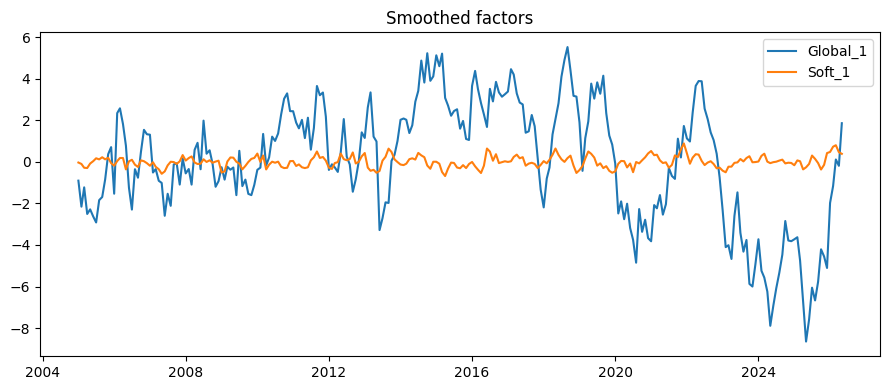

In [12]:
ax = plots.plot_factors(model, data_sel)
plt.tight_layout(); plt.show()

## 6. Model evaluation

**What it does.** `evaluate` re-runs the model in **pseudo real time**: for
every quarter in the window and every month within it, the data are cut to
what would actually have been available (using each series' `pub_lag`), the
model is re-estimated, and predictions are made for up to three horizons —
**backcast** (previous quarter), **nowcast** (current), **forecast** (next).
`evaluation_summary` reports **RMSE** and **FDA** (Forecast Directional
Accuracy) against an AR(1) benchmark, optionally split by sub-period.

**What you can configure.** `start`/`end`, `months_in_quarter`, `horizons`,
`refit` (re-estimate every vintage or not), and `subperiods` in the summary
(e.g. `pn.DEFAULT_SUBPERIODS` for the pre-Covid/Covid/post-Covid split).

In [13]:
results = pn.evaluate(
    lambda: pn.DFM(factors={"Global": 1, "Soft": 1}, lags=2),
    data_sel, start="2025Q1", end="2025Q4",
    horizons=("backcast", "nowcast", "forecast"),
    verbose=False,
)
pn.evaluation_summary(results).round(3)

rmse_model  rmse_ar1  fda_model  fda_ar1  n  relative_rmse
horizon  month_in_quarter                                                            
backcast 1                      0.408     1.050       1.00      0.5  4          0.389
forecast 1                      1.573     1.800       0.50      0.5  4          0.874
         2                      1.296     1.670       0.75      0.5  4          0.776
         3                      1.385     1.670       0.75      0.5  4          0.829
nowcast  1                      0.880     1.453       0.75      0.5  4          0.606
         2                      0.541     1.066       1.00      0.5  4          0.508
         3                      0.426     1.066       1.00      0.5  4          0.400

`relative_rmse` below 1 means the model beats the AR(1) benchmark; accuracy
should improve as the quarter progresses and more data arrive.

In [14]:
# sub-period breakdown (here: first vs second half of 2025)
pn.evaluation_summary(
    results, by=("horizon",),
    subperiods={"2025 H1": ("2025Q1", "2025Q2"),
                "2025 H2": ("2025Q3", "2025Q4")},
).round(3)

rmse_model  rmse_ar1  fda_model  fda_ar1  n  relative_rmse
subperiod horizon                                                             
2025 H1   backcast       0.456     1.473      1.000      0.0  2          0.310
          forecast       2.074     2.361      0.000      0.0  3          0.879
          nowcast        0.792     1.553      0.833      0.0  6          0.510
2025 H2   backcast       0.499     0.243      1.000      1.0  1          2.050
          forecast       0.713     1.249      1.000      1.0  6          0.571
          nowcast        0.454     0.715      1.000      1.0  6          0.634

## 7. Policy interpretation & plots

The point nowcast is only the start. These outputs explain *where it comes
from* and *how uncertain it is* — the operational layer of the original
toolbox.

### 7a. News decomposition — why did the nowcast move?

**What it does.** Between two data vintages, `news_decomposition` splits the
change in the nowcast into **data revisions** and series-by-series **news**
(`released − expected`, weighted by the Kalman gain). The identity
`new = old + revisions + Σ news` holds to machine precision.

**What you can configure.** The two vintages (any `data.vintage("YYYY-MM")`)
and the target period.

Nowcast of GDP for 2026Q2
  old vintage : -0.340
  new vintage : -0.504
  change      : -0.163
    of which revisions : +0.000
    of which news      : -0.163
  main news contributions:
    GDP                  -0.219
    survey_10            +0.039
    survey_9             +0.019
    survey_8             -0.012
    survey_11            +0.008
    hard_6               -0.004
    hard_1               +0.003
    hard_3               +0.001


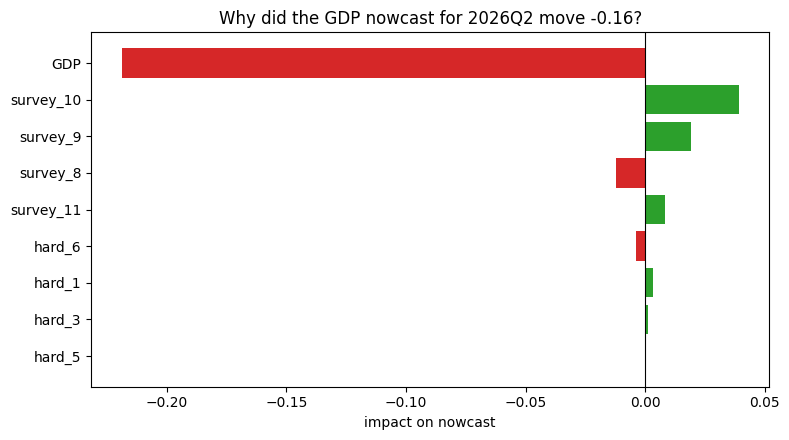

In [15]:
old = data_sel.vintage("2026-04")
new = data_sel.vintage("2026-05")
news = pn.news_decomposition(model, old, new, target="GDP", period=TARGET_Q)
print(news.summary())

ax = plots.plot_news(news)
plt.tight_layout(); plt.show()

### 7b. Approximate contributions

**What it does.** Attributes the nowcast to groups of variables, proxied by
the news from all releases over the past two years; `Mean` is the value the
model reverts to absent recent data. `mean + Σ contributions = prediction`.

**What you can configure.** `lookback` (months) and `by_group`.

mean = +0.16
group
Surveys    -0.708
Target     -0.181
Trade      -0.021
Industry   -0.018


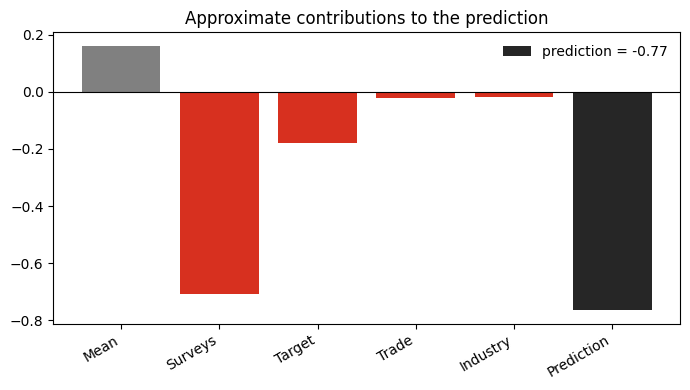

In [16]:
contr, mean_ = pn.contributions(model, data_sel, period=TARGET_Q,
                                lookback=24, by_group=True)
print(f"mean = {mean_:+.2f}")
print(contr.round(3).to_string())

ax = plots.plot_contributions(contr, mean_)
plt.tight_layout(); plt.show()

### 7c. Heatmap of input variables

**What it does.** Shows each input's recent z-score (monthly series smoothed
over five months per the Mariano–Murasawa approximation); grey = not yet
released. A quick read of which indicators are running hot or cold.

**What you can configure.** `last` (number of months shown), `smooth`,
`by_group`.

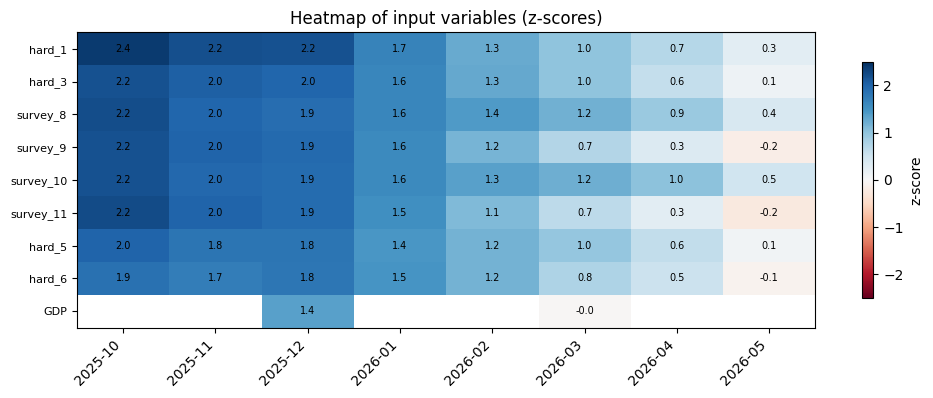

In [17]:
ax = plots.plot_heatmap(data_sel, last=8)
plt.show()

### 7d. Confidence bands

**What it does.** Bands à la Reifschneider & Tulip (2019): the rolling Mean
Absolute Error of past pseudo-real-time predictions (outlier-adjusted as in
ECB 2009), per horizon × month of quarter. `± 1 MAE` ≈ a 57.5% interval.

**What you can configure.** `years` of history, or pass a pre-computed
`results` frame to skip the evaluation loop (we reuse the one from step 6).

In [18]:
bands = pn.confidence_bands(None, data_sel, results=results)
print(bands.round(3).to_string())

band = pn.prediction_with_bands(point, bands, horizon="nowcast",
                                month_in_quarter=2)
print(f"\nnowcast {TARGET_Q}: {band['point']:+.2f} "
      f"[{band['lower']:+.2f}, {band['upper']:+.2f}]  (57.5% CI)")

                             mae   fda  n  sigma
horizon  month_in_quarter                       
backcast 1                 0.304  1.00  4  0.380
forecast 1                 1.464  0.50  4  1.835
         2                 1.080  0.75  4  1.353
         3                 1.261  0.75  4  1.580
nowcast  1                 0.704  0.75  4  0.882
         2                 0.419  1.00  4  0.526
         3                 0.363  1.00  4  0.455

nowcast 2026Q2: -0.77 [-1.18, -0.35]  (57.5% CI)


### 7e. Range of alternative models & data coverage

**What it does.** `alternative_range` recomputes the nowcast while
disconnecting one or two **groups** of variables at a time (`do_range`),
showing how much the result depends on, say, surveys.
`share_of_available_data` reports how much of the target quarter's monthly
data has actually been released.

**What you can configure.** `max_drop` (1 or 2 groups), and the model
factory used for the alternatives.

excluded  n_excluded  prediction
  (none)           0      -0.766
Industry           1      -0.750
   Trade           1      -0.729
 Surveys           1      -0.698

Share of 2026Q2 monthly data available in the May vintage: 25%


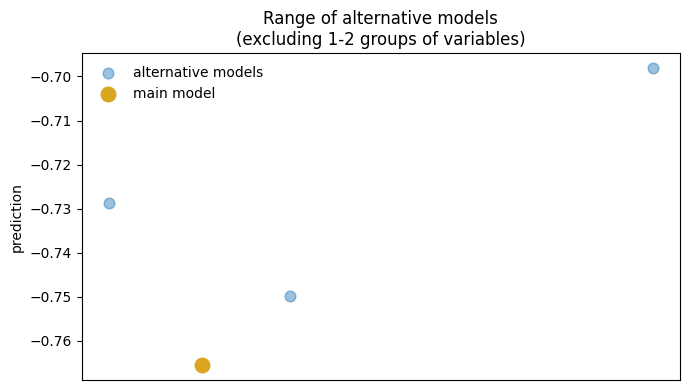

In [19]:
rng = pn.alternative_range(
    lambda: pn.DFM(factors=1, lags=2), data_sel, period=TARGET_Q, max_drop=1)
print(rng.round(3).to_string(index=False))

share = pn.share_of_available_data(data_sel.vintage("2026-05"), TARGET_Q)
print(f"\nShare of {TARGET_Q} monthly data available in the May vintage: {share:.0%}")

ax = plots.plot_range(rng)
plt.tight_layout(); plt.show()

### 7f. Nowcast evolution

Finally, how the nowcast for the target quarter evolved as data arrived
across successive vintages.

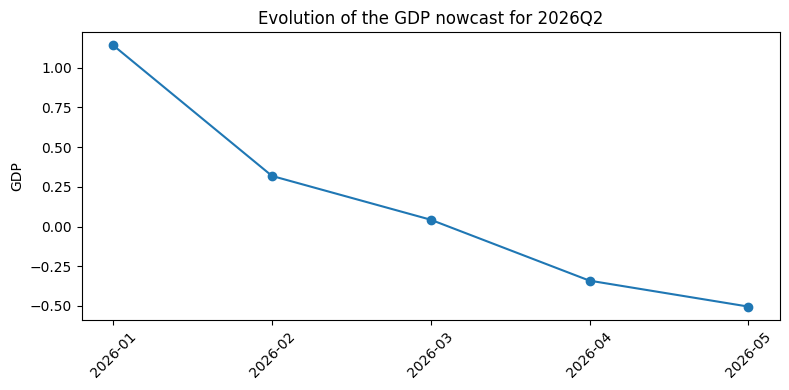

In [20]:
ax = plots.plot_nowcast_evolution(model, data_sel, period=TARGET_Q)
plt.tight_layout(); plt.show()

---

## Recap

You have run a full nowcasting exercise: **import → transform (Covid &
outliers) → pre-select → model-select → fit → evaluate → interpret**.

To adapt it to your own data, replace step 1 with
`pn.load_data("your_file.xlsx", target="...")` using the same Excel layout
(sheets `monthly`, `quarterly`, `spec`), then re-run the cells. Key knobs:
the `transform`/`pub_lag`/`group`/`block_*` columns of the spec, the Covid
`method`, `N_KEEP` in pre-selection, the `bounds` in the search, and the
model class in step 5.